In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [62]:
df=pd.read_csv('/content/Walmart DataSet.csv')
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [64]:
df.shape

(6435, 8)

In [65]:
df.describe().round(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00
std,12.99,564366.62,0.26,18.44,0.46,39.36,1.88
min,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88
25%,12.00,553350.10,0.00,47.46,2.93,131.74,6.89
50%,23.00,960746.04,0.00,62.67,3.44,182.62,7.87
75%,34.00,1420158.66,0.00,74.94,3.74,212.74,8.62
max,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31


In [66]:
df.isna().sum().sum()


np.int64(0)

In [67]:
df.isin(['Missing','NA',' ','NULL',"", "NA", "N/A", "?", "null", "None"]).sum().sum()

np.int64(0)

In [68]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Store', ylabel='Weekly_Sales'>

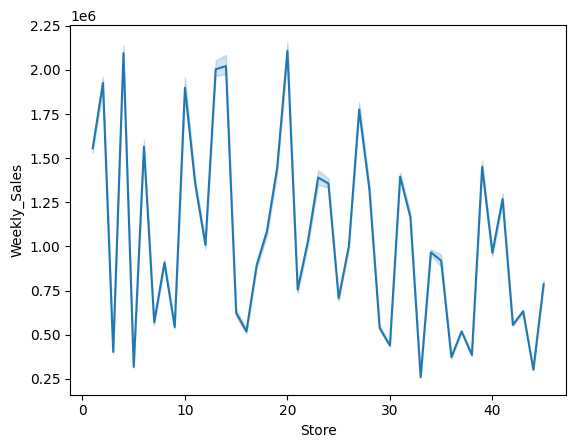

In [69]:
sns.lineplot(x='Store', y='Weekly_Sales', data=df)

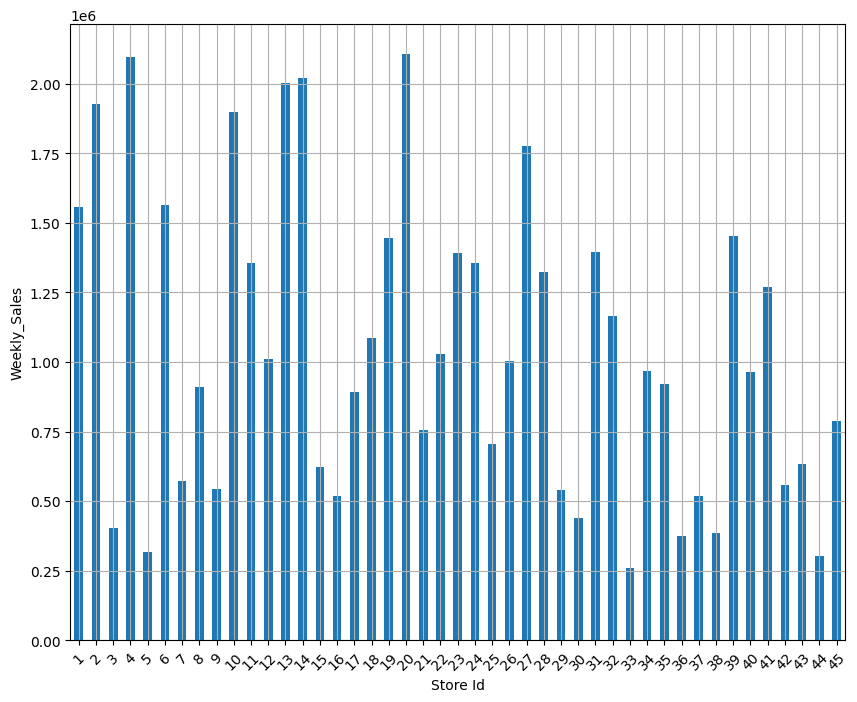

In [70]:
plt.figure(figsize=(10,8))
df.groupby("Store")["Weekly_Sales"].mean().plot(kind='bar')
plt.grid()
plt.xticks(rotation=45)
plt.xlabel("Store Id")
plt.ylabel("Weekly_Sales")
plt.show()

**Highest Sales store is 20
  Lowest Sale store is 33 **

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

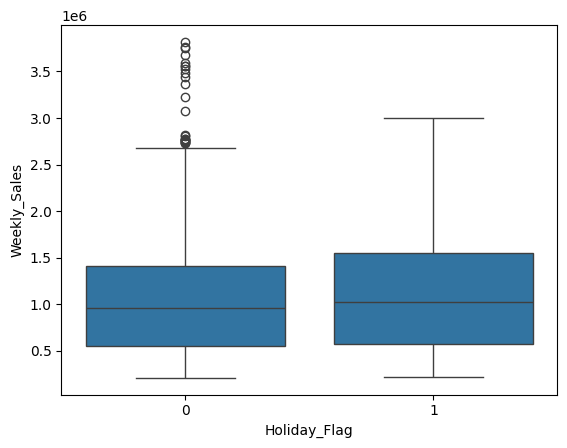

In [71]:
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

Holiday weeks generate higher sales than regular weeks.

<Axes: >

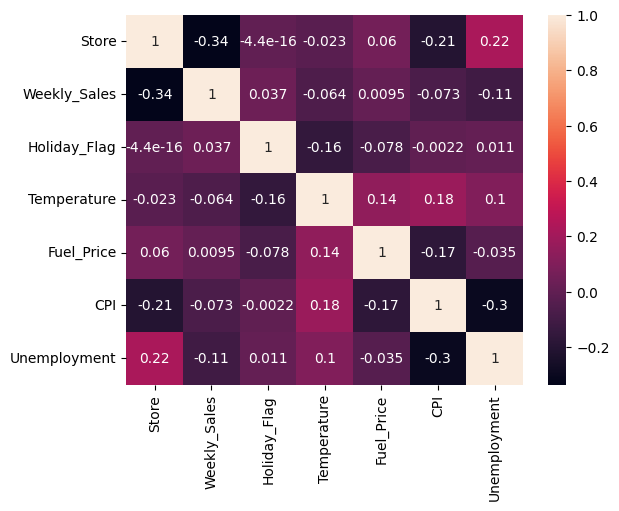

In [72]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Weekly Sales


Temperature= -0.064  Very weak negative relationship with Weekly Sales

Fuel Price = 0.0095  No relationship with Weekly sales

CPI =-0.073  Very weak negative relationship with Weekly Sales

Unemployment = -0.11  Very weak negative relationship with Weekly Sales



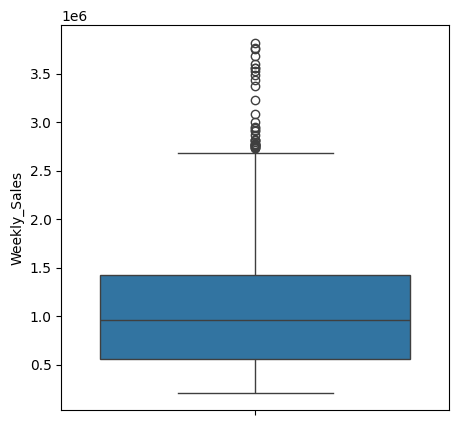

In [73]:
plt.figure(figsize=(5,5))
sns.boxplot(df["Weekly_Sales"])
plt.show()

In [74]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR



In [75]:
outliers = df[(df['Weekly_Sales'] < lower) | (df['Weekly_Sales'] > upper)]


In [76]:
print("Number of outliers:", len(outliers))
outliers.head(34)

Number of outliers: 34


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,24-12-2010,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,23-12-2011,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,26-11-2010,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,17-12-2010,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,24-12-2010,3526713.39,0,43.21,2.887,126.983581,7.127
523,4,25-11-2011,3004702.33,1,47.96,3.225,129.836400,5.143
526,4,16-12-2011,2771397.17,0,36.44,3.149,129.898065,5.143
527,4,23-12-2011,3676388.98,0,35.92,3.103,129.984548,5.143
761,6,24-12-2010,2727575.18,0,55.07,2.886,212.916508,7.007
1329,10,26-11-2010,2939946.38,1,55.33,3.162,126.669267,9.003


In [77]:
outliers['Date']=pd.to_datetime(outliers['Date']).dt.month_name()


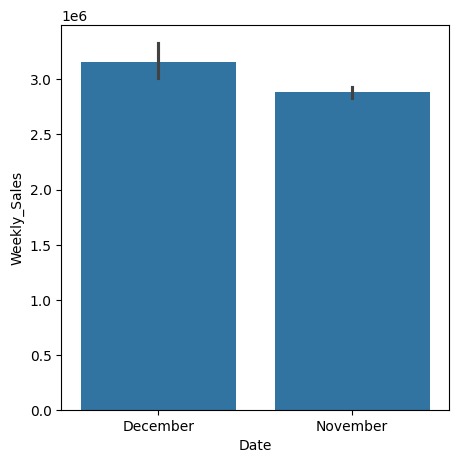

In [78]:
plt.figure(figsize=(5,5))
sns.barplot(outliers,x='Date',y='Weekly_Sales')
plt.show()

All the outliers in the Weekly Sales are during the months of November and December which are the festive months of Thanksgiving and Christmas when the sales volume would be at the peak

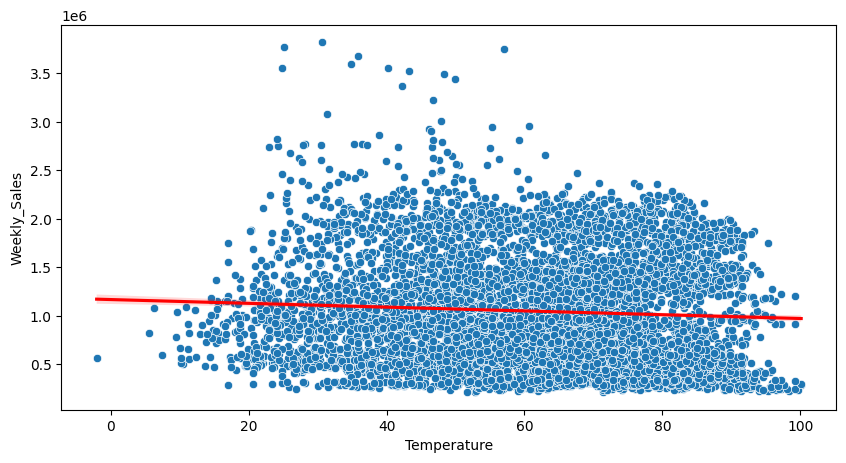

In [79]:
plt.figure(figsize=(10,5))
sns.scatterplot(df,x='Temperature',y='Weekly_Sales')
sns.regplot(data=df,x='Temperature',y='Weekly_Sales',scatter=False,color='Red')
plt.show()


In [80]:
corr = df['Temperature'].corr(df['Weekly_Sales'])
print(f"Correlation: {corr:.3f}")

Correlation: -0.064


Sales are more where the temperature is between 40-80,have very weak negative correlation with weekly sales

In [81]:
top = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

In [82]:
top.head(5)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08


In [83]:
bottom=df.groupby("Store")["Weekly_Sales"].sum().sort_values()

In [84]:
bottom.head()

,Weekly_Sales
Store,
33,37160221.96
44,43293087.84
5,45475688.90
36,53412214.97
38,55159626.42


In [85]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean().round(2)

,Weekly_Sales
Holiday_Flag,
0,1041256.38
1,1122887.89


Holiday weeks produce higher average weekly sales due to increased consumer spending.

Business Insights

Holiday weeks significantly increase weekly sales.
A small number of stores contribute a large share of total revenue.
Weekly sales contain seasonal peaks, especially near major holidays.
Fuel price has little influence on sales.
Unemployment has a weak negative relationship with sales.
Temperature shows limited impact on overall sales.
Sales vary substantially across stores, suggesting differences in location and customer demand.
Outliers are mostly associated with legitimate high-demand periods rather than data errors.


In [86]:

#df['Date']=pd.to_datetime(df['Date'],errors='coerce',format='%d/%m/%Y')

In [87]:
df['Parsed_Date'] = pd.to_datetime(df['Date'], errors='coerce')

df[df['Parsed_Date'].isna()][['Date']]

,Date
2,19-02-2010
3,26-02-2010
6,19-03-2010
7,26-03-2010
10,16-04-2010
...,...
6428,14-09-2012
6429,21-09-2012
6430,28-09-2012
6433,19-10-2012


In [88]:

print(df['Parsed_Date'].isna().sum())

3870


In [89]:
#invalid = df.loc[df['Parsed_Date'].isna(), 'Date'].unique()
#print(invalid)

In [90]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y',errors='coerce')

In [91]:
df['Date'].isna().sum().sum()

np.int64(0)

In [92]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day_of_Week'] = df['Date'].dt.dayofweek

monthly_yearly_sales = (df.groupby(['Year', 'Month'], as_index=False)['Weekly_Sales'].sum().rename(columns={'Weekly_Sales': 'Sales'}))
# Create a Year-Month date column
monthly_yearly_sales['YearMonth'] = pd.to_datetime(monthly_yearly_sales[['Year', 'Month']].assign(DAY=1))


In [93]:
import matplotlib.dates as mdates

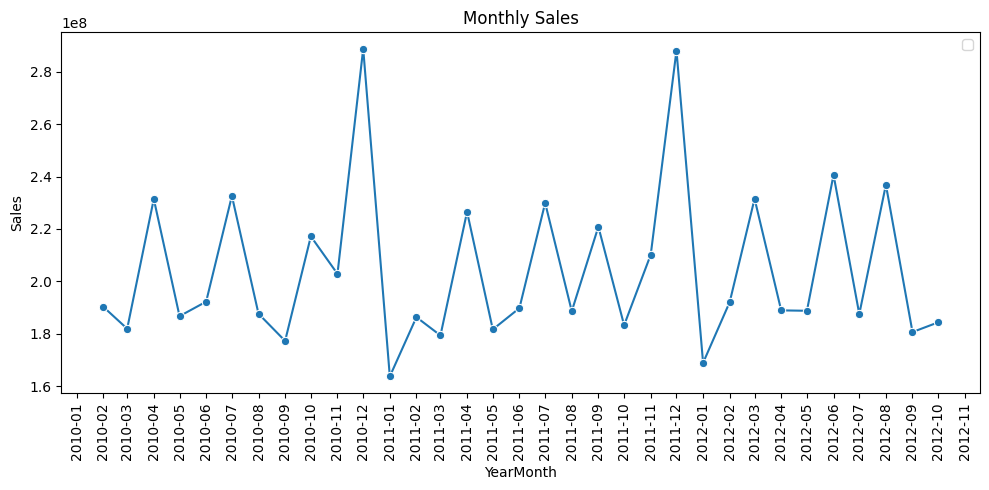

In [94]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_yearly_sales,x='YearMonth', y='Sales',marker='o')
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=90)
plt.title('Monthly Sales')
plt.tight_layout()
plt.show()


In [95]:

monthly_yearly_sales_hol=df.groupby(['Year','Month','Holiday_Flag'],as_index=False)['Weekly_Sales'].sum().rename(columns={'Weekly_Sales': 'Sales'})


In [96]:
monthly_yearly_sales_hol['YearMonth']=pd.to_datetime(monthly_yearly_sales_hol[['Year','Month']].assign(DAY=1))

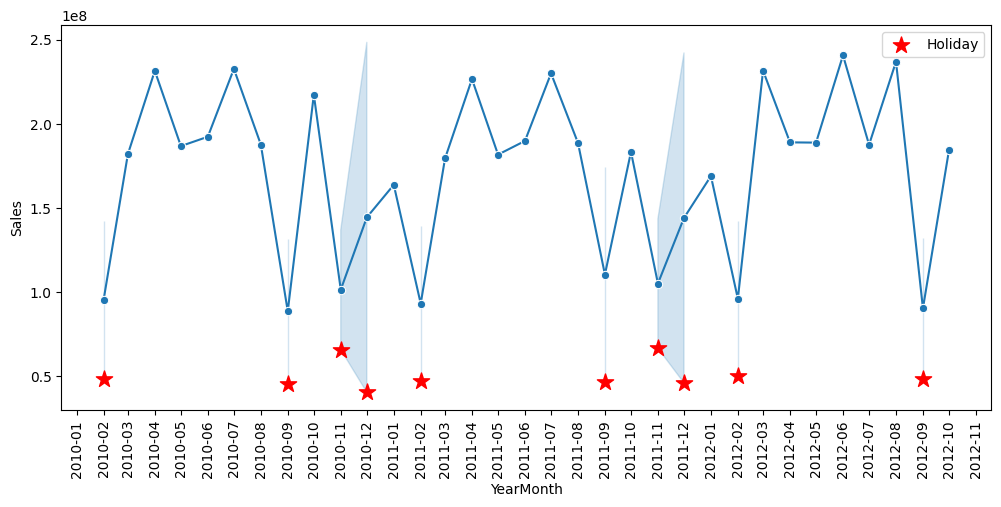

In [97]:
plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_yearly_sales_hol,x='YearMonth',y='Sales',marker='o')

holiday = monthly_yearly_sales_hol[monthly_yearly_sales_hol['Holiday_Flag']==1]
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.scatter(holiday['YearMonth'],holiday['Sales'],color='red',marker='*',s=150,label='Holiday')
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [98]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


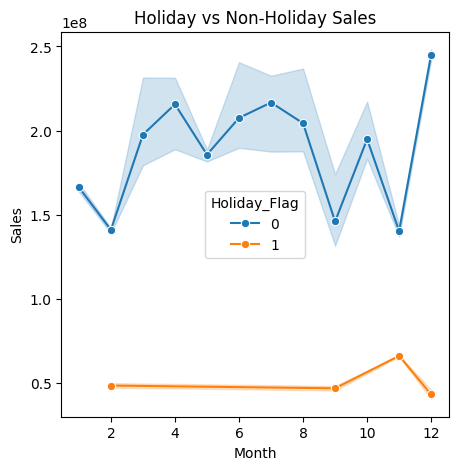

In [99]:
plt.figure(figsize=(5,5))
sns.lineplot(data=monthly_yearly_sales_hol,x='Month',y='Sales',hue='Holiday_Flag',marker='o')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Parsed_Date   2565 non-null   datetime64[ns]
 9   Year          6435 non-null   int32         
 10  Month         6435 non-null   int32         
 11  Day_of_Week   6435 non-null   int32         
dtypes: datetime64[ns](2), float64(5), int32(3), int64(2)
memory usage: 528.0 KB


In [101]:

a=int(input(print("Enter the Store Id(1-45): ")))
print(f"The Store_Id is : {a}")
store=df[df['Store']==a]


Enter the Store Id(1-45): 
None25
The Store_Id is : 25


In [102]:
store

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Parsed_Date,Year,Month,Day_of_Week
3432,25,2010-02-05,677231.63,0,21.10,2.784,204.247194,8.187,2010-05-02,2010,2,4
3433,25,2010-02-12,583364.02,1,19.64,2.773,204.385747,8.187,2010-12-02,2010,2,4
3434,25,2010-02-19,676260.67,0,24.16,2.745,204.432100,8.187,NaT,2010,2,4
3435,25,2010-02-26,628516.57,0,29.16,2.754,204.463087,8.187,NaT,2010,2,4
3436,25,2010-03-05,665750.06,0,29.45,2.777,204.494073,8.187,2010-05-03,2010,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...
3570,25,2012-09-28,683300.84,0,54.52,3.997,215.736716,7.280,NaT,2012,9,4
3571,25,2012-10-05,699536.73,0,57.58,3.985,215.925886,7.293,2012-05-10,2012,10,4
3572,25,2012-10-12,697317.41,0,43.74,4.000,216.115057,7.293,2012-12-10,2012,10,4
3573,25,2012-10-19,685531.85,0,51.93,3.969,216.146470,7.293,NaT,2012,10,4


In [103]:
store = store.set_index('Date')

In [113]:
store=pd.DataFrame(store)

In [115]:
store=store.groupby(pd.Grouper(freq='W'))['Weekly_Sales'].sum()

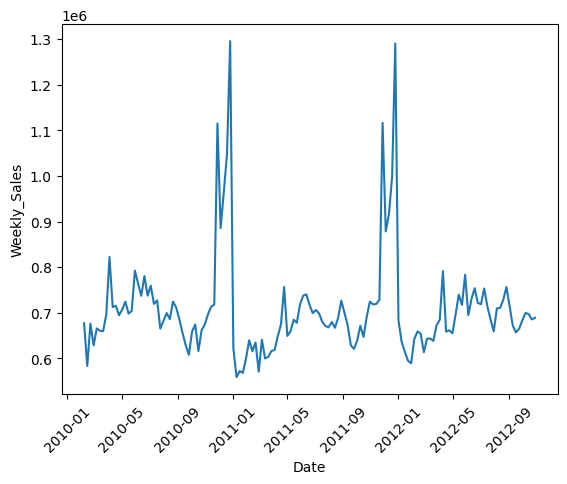

In [116]:
sns.lineplot(store)
plt.xticks(rotation=45)
plt.show()

In [117]:
from statsmodels.tsa.stattools import adfuller

In [119]:
result = adfuller(store)

In [120]:
if result[1]<0.05:
   print(f"Data is Stationary,p_value:{result[1]}")
else:
   print("Non Stationary")

Data is Stationary,p_value:1.6841077210502291e-06


In [121]:
store.shape

(143,)

In [133]:
df_train=store.iloc[:114].to_frame()
df_test=store.iloc[114:].to_frame()

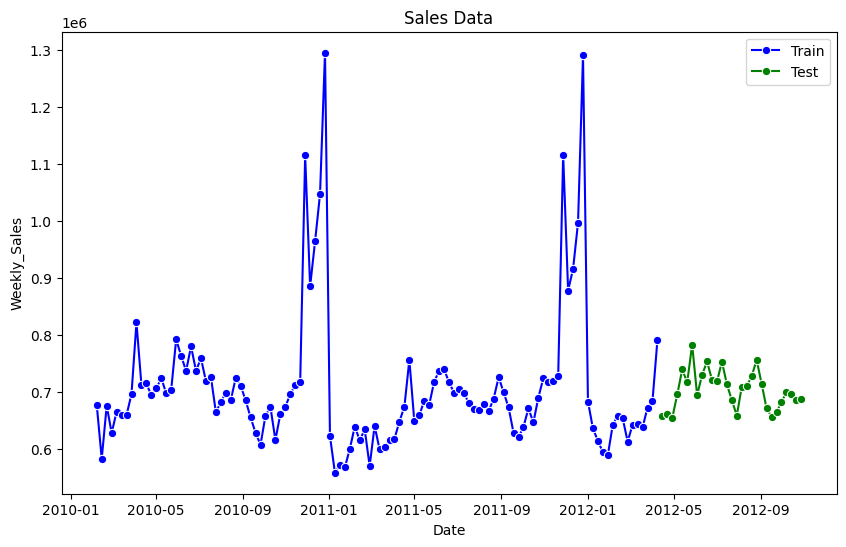

In [134]:
plt.figure(figsize = (10, 6))
sns.lineplot(data = df_train, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
plt.title('Sales Data');

In [136]:
from statsmodels.tsa.seasonal import seasonal_decompose

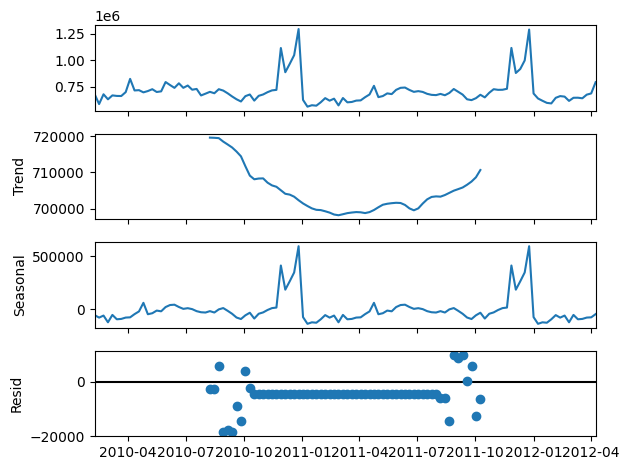

In [137]:
seasonal_decompose(df_train).plot();

In [138]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x500 with 0 Axes>

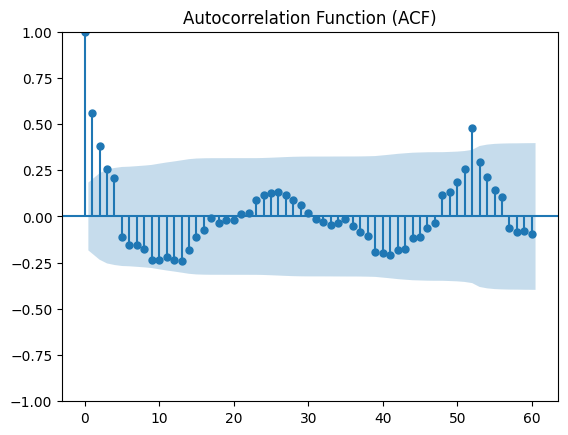

In [140]:
plt.figure(figsize=(12,5))

plot_acf(df_train,lags=60)

plt.title("Autocorrelation Function (ACF)")
plt.show()

In [141]:
from statsmodels.graphics.tsaplots import plot_pacf

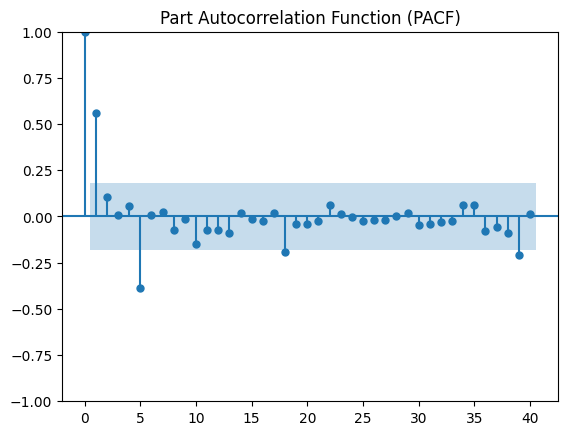

In [143]:
plot_pacf(df_train,lags=40)

plt.title("Part Autocorrelation Function (PACF)")
plt.show()

Since the data is stationary ,no differencing is required hence d=0.

In [144]:
from statsmodels.tsa.arima.model import ARIMA

In [157]:
from sklearn.metrics import *
import itertools
p=range(0,7)
d=range(0,1)
q=range(0,7)
pdq=list(itertools.product(p,d,q))
#pdq


In [212]:
#finding optimal values of p,d,q with itertools
import itertools
p=range(1,7)
d=range(0,1)
q=range(1,7)
pdq=list(itertools.product(p,d,q))
rmse = []
order1 =[]

for i in pdq:
    try:
        model = ARIMA(df_train['Weekly_Sales'], order = i)
        model_fit = model.fit()


        forecast = model_fit.forecast(steps=len(df_test['Weekly_Sales']))


        error = np.sqrt(mean_squared_error(df_test['Weekly_Sales'],forecast  ))
        order1.append(i)
        rmse.append(error)
    except:
     continue

results = pd.DataFrame(index = order1, data = rmse, columns=['RMSE'])
print(results)



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

                   RMSE
(1, 0, 1)  38210.310810
(1, 0, 2)  38330.698796
(1, 0, 3)  39043.805854
(1, 0, 4)  41265.708167
(1, 0, 5)  41725.837616
(1, 0, 6)  41493.822236
(2, 0, 1)  38309.697971
(2, 0, 2)  39535.156717
(2, 0, 3)  39100.442331
(2, 0, 4)  41169.518992
(2, 0, 5)  41843.994467
(2, 0, 6)  41587.906545
(3, 0, 1)  39378.145373
(3, 0, 2)  41481.548530
(3, 0, 3)  39546.642101
(3, 0, 4)  41542.196147
(3, 0, 5)  44654.535569
(3, 0, 6)  46609.460820
(4, 0, 1)  37551.631850
(4, 0, 2)  41417.449944
(4, 0, 3)  41050.353111
(4, 0, 4)  46326.115066
(4, 0, 5)  46932.721242
(4, 0, 6)  45814.380766
(5, 0, 1)  45596.794384
(5, 0, 2)  45170.274783
(5, 0, 3)  40745.727838
(5, 0, 4)  43092.800278
(5, 0, 5)  46474.458291
(5, 0, 6)  46035.067461
(6, 0, 1)  45667.006271
(6, 0, 2)  44904.712128
(6, 0, 3)  42640.127276
(6, 0, 4)  42704.965173
(6, 0, 5)  47292.158154
(6, 0, 6)  44825.540859


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


From the above calculate MSE is minimum when p and q are 1

In [171]:
best_result=results.sort_values(by='RMSE',ascending=True).iloc[0]
print (best_result)

RMSE    33481.130474
Name: (0, 0, 0), dtype: float64


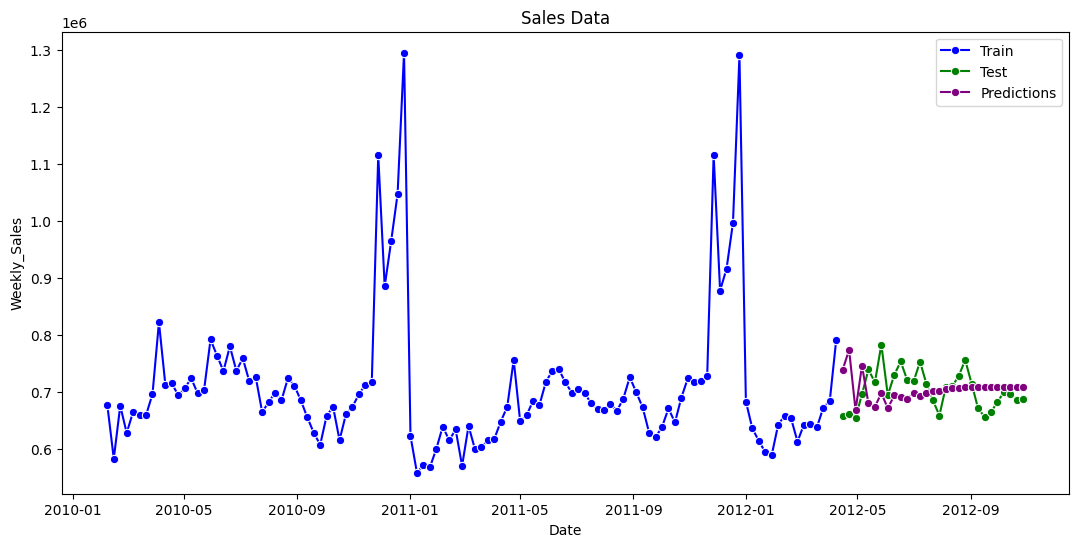

In [226]:
plt.figure(figsize = (13, 6))
sns.lineplot(data = df_train, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = forecast.index, y = forecast.values, marker = 'o', color = 'purple', label = 'Predictions')
#sns.lineplot(x = future_forecast .index, y = future_forecast .values, marker = 'o', color = 'red', label = 'fu_Predictions')

plt.legend()
plt.title('Sales Data');
plt.show()

In [179]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [214]:
sarima_model = SARIMAX(df_train['Weekly_Sales'], order = (1, 0, 1), seasonal_order = (1, 0,1, 52))
sarima_model = sarima_model.fit()
sarima_model_preds = sarima_model.forecast(steps=len(df_test))



In [186]:
train_len = 114


   # forecast = model_fit.forecast(steps=len(df_test['Weekly_Sales']))

In [191]:
sarima_model_preds

,predicted_mean
2012-04-15,762086.877415
2012-04-22,807599.708221
2012-04-29,737140.735474
2012-05-06,738860.851411
2012-05-13,749774.274356
2012-05-20,741143.875717
2012-05-27,761820.206511
2012-06-03,769132.900893
2012-06-10,766407.577633
2012-06-17,748286.849199


In [193]:
df_preds = sarima_model_preds

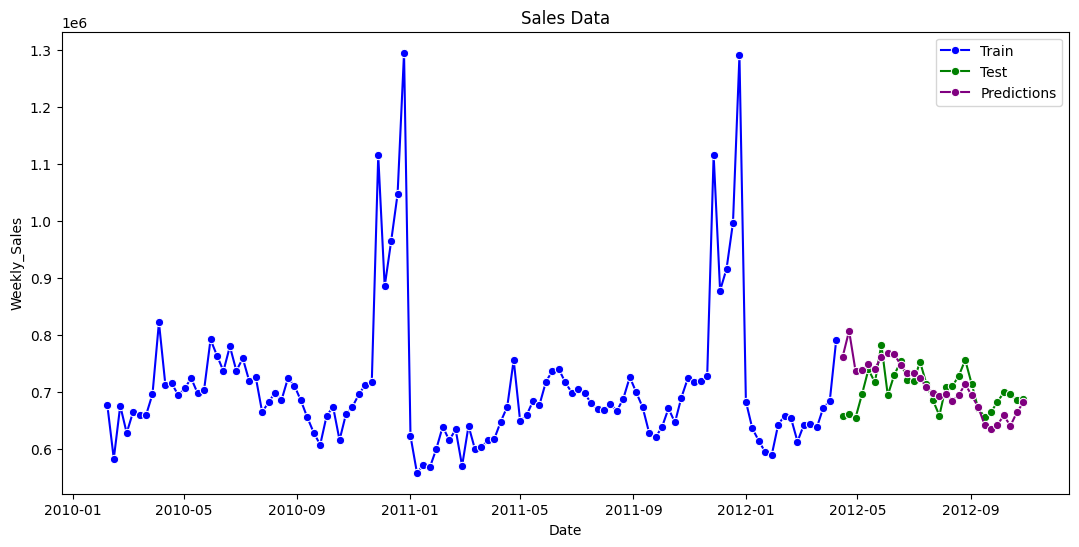

In [194]:


plt.figure(figsize = (13, 6))
sns.lineplot(data = df_train, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x ='Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds.index, y = df_preds.values, marker = 'o', color = 'purple', label = 'Predictions')
plt.legend()
plt.title('Sales Data');
plt.show()

In [231]:
RMSE_SARIMA=np.sqrt(root_mean_squared_error(df_test['Weekly_Sales'],df_preds   ))
RMSE_ARIMA=np.sqrt(root_mean_squared_error(df_test['Weekly_Sales'],forecast   ))

In [232]:
print(RMSE_SARIMA)
print(RMSE_ARIMA)

216.1197671260823
211.7204308974244


Business Insights

Although the sales data exhibited yearly seasonal patterns, the SARIMA model did not improve forecasting accuracy. ARIMA achieved a lower RMSE (211) compared with SARIMA (216), indicating that the additional seasonal component did not provide significant predictive improvement for this dataset. This may be due to limited seasonal observations and irregular holiday demand spikes

In [244]:
future_dates_ARIMA = pd.date_range(start=store.index[-1],periods=len(df_test),freq='W')

forecast_df_ARIMA = pd.DataFrame({'Date': future_dates,'Predicted_Sales': forecast.values})

print(forecast_df_ARIMA)


         Date  Predicted_Sales
0  2012-10-28    739179.831250
1  2012-11-04    774387.948195
2  2012-11-11    668346.959741
3  2012-11-18    746469.639983
4  2012-11-25    680265.736062
5  2012-12-02    674447.225136
6  2012-12-09    698409.652208
7  2012-12-16    671845.458812
8  2012-12-23    694290.779238
9  2012-12-30    692230.365231
10 2013-01-06    688229.167489
11 2013-01-13    698580.495809
12 2013-01-20    694051.847049
13 2013-01-27    699139.563099
14 2013-02-03    702719.109450
15 2013-02-10    702533.169640
16 2013-02-17    706494.514889
17 2013-02-24    706674.126119
18 2013-03-03    707568.612947
19 2013-03-10    708894.446887
20 2013-03-17    708683.232040
21 2013-03-24    709409.868087
22 2013-03-31    709457.579761
23 2013-04-07    709277.535539
24 2013-04-14    709348.683370
25 2013-04-21    708989.937031
26 2013-04-28    708802.648527
27 2013-05-05    708586.974511
28 2013-05-12    708288.044818


In [245]:
forecast_df_ARIMA.to_csv('next_12_week_forecast_arima.csv', index=False)

In [246]:
future_dates_SARIMA = pd.date_range(start=store.index[-1],periods=len(df_test),freq='W')

forecast_df_SARIMA = pd.DataFrame({'Date': future_dates,'Predicted_Sales': df_preds.values})

print(forecast_df_SARIMA)

forecast_df_SARIMA.to_csv('next_12_week_forecast_sarima.csv', index=False)

         Date  Predicted_Sales
0  2012-10-28    762086.877415
1  2012-11-04    807599.708221
2  2012-11-11    737140.735474
3  2012-11-18    738860.851411
4  2012-11-25    749774.274356
5  2012-12-02    741143.875717
6  2012-12-09    761820.206511
7  2012-12-16    769132.900893
8  2012-12-23    766407.577633
9  2012-12-30    748286.849199
10 2013-01-06    732858.038561
11 2013-01-13    733069.914958
12 2013-01-20    724160.066552
13 2013-01-27    709126.440972
14 2013-02-03    699037.505926
15 2013-02-10    693686.423380
16 2013-02-17    696842.077216
17 2013-02-24    685289.795734
18 2013-03-03    695071.456311
19 2013-03-10    714315.513847
20 2013-03-17    694244.825551
21 2013-03-24    674278.851918
22 2013-03-31    643333.633933
23 2013-04-07    634962.793182
24 2013-04-14    642904.122160
25 2013-04-21    659411.432823
26 2013-04-28    640765.279599
27 2013-05-05    664459.507664
28 2013-05-12    681956.651415
